In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import time


In [2]:
class Items:
    def __init__(self, n_items, embedding_dim, Wi):
        self.n_items = n_items
        self.embedding_dim = embedding_dim
        self.input_embedding_Wi = Wi
        self.one_hots = tf.cast(tf.keras.utils.to_categorical(tf.range(self.n_items, dtype=tf.int64).numpy(),
                                                      num_classes=self.n_items), tf.float32)
        self._one_hots_embedded = None
        self.embed_from_one_hot()
    
    def __repr__(self):
        return f"Items(n_items={self.n_items}, embedding_dim={self.embedding_dim})"

    def embed_from_one_hot(self):
        self._one_hots_embedded = tf.tensordot(self.input_embedding_Wi, self.one_hots, axes=1)
    
    def update_embedding(self, new_Wi):
        self.input_embedding_Wi = new_Wi
        self.embed_from_one_hot()

In [3]:
class Transaction(Items):
    def __init__(self, n_items, embedding_dim, Wi, Wo, transaction_items=None, n_items_transaction=5):
        super().__init__(n_items, embedding_dim, Wi)
        if transaction_items != None:
            self.transaction_items = tf.convert_to_tensor(transaction_items, dtype=tf.int32)
            self.n_items_transaction = len(self.transaction_items)
        else:
            self.transaction_items = None
            self.n_items_transaction = n_items_transaction
        self.output_embedding_Wo  = Wo
        self.scores = np.zeros((self.n_items_transaction,self.n_items) )
        if self.transaction_items == None:
            self._sample()
    
    def __repr__(self):
        return f"{self.transaction_items.numpy()}"
  
    def _sample(self):
        indices = tf.range(self.n_items, dtype=tf.int64)
        shuffled = tf.random.shuffle(indices)
        sample = shuffled[:self.n_items_transaction]
        self.transaction_items= sample
        return sample
    
    def describe(self):
        print("Transaction:", self.transaction_items.numpy())

    
    def update_embedding(self, new_Wi, new_Wo):
        super().update_embedding(new_Wi)
        self.output_embedding_Wo = new_Wo

In [ ]:
class Context:
    def __init__(self, transaction, wa, target_item = None):
        self.context_embedding_wa = wa
        self.Theta = [transaction.input_embedding_Wi, 
                      self.context_embedding_wa, 
                      transaction.output_embedding_Wo]
        self.transaction = transaction
        if target_item is None:
            target_item = random.choice(transaction.transaction_items.numpy())
        elif target_item not in transaction.transaction_items.numpy():
            raise ValueError("Target item must be part of the transaction items.")
        
        self.target_item = target_item
        self.context_items = tf.boolean_mask(self.transaction.transaction_items, self.transaction.transaction_items != target_item)
        self.context_embedding = None
        self.alpha_weights = None
        if self.alpha_weights is None:
            self._compute_alpha_weights()

    
    def __repr__(self):
        return f"context items ={self.context_items.numpy()}"
    
    
    def _compute_alpha_weights(self):
        e_h = tf.linalg.matvec(tf.transpose(tf.gather(self.transaction._one_hots_embedded, self.context_items, axis=1)),
                                self.context_embedding_wa) 
        exponents = tf.exp(e_h)
        self.alpha_weights = exponents / tf.reduce_sum(exponents)
    

    def _context_embed(self):
        Wi, wa, Wo = self.Theta 
        self.context_embedding = tf.tensordot(tf.gather(self.transaction._one_hots_embedded, self.context_items, axis=1),self.alpha_weights, axes=1)
        #self.all_items_scores = tf.tensordot(Wo, self.context_embedding, axes=1)
        #Z_c = tf.reduce_sum(tf.exp(self.all_items_scores), axis=0)
        #self.target_item_relevance_to_context = tf.exp(self.all_items_scores[self.target_item])/Z_c

    def score(self, item):
        Wi, wa, Wo = self.Theta 
        return tf.tensordot(Wo[item], self.context_embedding, axes=1)
        

    def describe(self):
        self._context_embed()
        print("Target item is", self.target_item," in the context:",self.context_items.numpy() )
        print("Context embedding shape:", self.context_embedding.shape)

    def update_embedding(self, new_Wi, new_Wo, new_wa):
        self.Theta[0] = new_Wi
        self.Theta[2] = new_Wo
        self.Theta[1] = new_wa
        self._context_embed()


In [54]:
I = 10
K = 2
Wi = tf.Variable(tf.random.normal((K, I), stddev=0.1), name='Wi')
Wo = tf.Variable(tf.random.normal((I, K), stddev=0.1), name='Wo')
wa = tf.Variable(tf.random.normal((K,), stddev=0.1), name='wa')
transaction = Transaction(I, K, Wi, Wo, n_items_transaction=8)
transaction.describe()

context = Context(transaction, wa=wa)
context.describe()

Transaction: [2 0 3 6 4 8 9 7]
Target item is 4  in the context: [2 0 3 6 8 9 7]
Context embedding shape: (2,)


In [55]:
n_baskets = 20
baskets = []
for _ in range(n_baskets):
    baskets.append(random.sample(range(I), 4))

transactions_ic = []
for i in range(n_baskets):
    transaction_items = baskets[i] 
    target_item = random.choice(transaction_items)
    context = Context(Transaction(I, K, Wi, Wo, transaction_items), wa=wa, target_item=target_item)
    context._context_embed()
    transactions_ic.append((context, target_item))

# Affichage de quelques transactions
for t in transactions_ic[:5]:
    print(t)
    print('Most relevant item:', np.array([t[0].score(i) for i in range(I)]).argmax())

(context items =[8 6 1], 5)
Most relevant item: 8
(context items =[5 6 1], 7)
Most relevant item: 1
(context items =[4 5 6], 7)
Most relevant item: 1
(context items =[3 2 4], 5)
Most relevant item: 3
(context items =[4 0 5], 6)
Most relevant item: 1


In [56]:
class Trainer:
    def __init__(self, data, Theta, lr = 0.05, K_noise = 3, epochs = 1500):
        self.contexts_and_target_item = data
        self.all_items = self.contexts_and_target_item[0][0].transaction.n_items
        self.Theta = Theta
        self.lr = lr
        self.K_noise = K_noise
        self.optimizer = tf.keras.optimizers.Adam(self.lr)
        self.epochs = epochs
        self.Q = [1.0 / self.all_items for _ in range(self.all_items)]

    def custom_loss(self, context, target_item): # prediction is a Context object
        transaction_items = context.transaction.transaction_items.numpy()
        neg_pool = []
        while len(neg_pool) < self.K_noise:
            candidate = random.randint(0, self.all_items - 1)
            if candidate not in transaction_items and candidate not in neg_pool:
                neg_pool.append(candidate)
        neg_items = np.array(neg_pool)
        def P_1_c(i_c):
            S = context.score(i_c)
            return tf.exp(S) / (tf.exp(S)+ self.K_noise*self.Q)[i_c]
        def P_0_c(i_c):
            return 1 - P_1_c(i_c)
        loss = -tf.math.log(P_1_c(target_item) + 1e-10)
        for i in neg_items:
            loss -= tf.math.log(P_0_c(i) + 1e-10)
        return loss

    def forward(self, context, target_item):
        return self.custom_loss(context, target_item)
    
    def fit(self, verbose = True):
        loss_history = []
        for epoch in range(self.epochs):
            time0 = time.time()
            with tf.GradientTape() as tape:
                total_loss = 0.0
                for ctx, target_item in self.contexts_and_target_item:
                    ctx.update_embedding(self.Theta[0], self.Theta[2], self.Theta[1])
                    loss = self.forward(ctx, target_item)

                    total_loss += loss
                total_loss = total_loss / len(self.contexts_and_target_item)
            #print("epoch ", epoch , " duration: ", time.time() - time0, end='\n')
            Wi, wa, Wo = self.Theta
            # backpropagation
            grads = tape.gradient(total_loss, [Wi, wa, Wo])
            self.optimizer.apply_gradients(zip(grads, [Wi, wa, Wo]))
            loss_history.append(total_loss.numpy())
            if verbose and epoch % 50 == 0:
                print(f"Epoch {epoch}, Loss: {total_loss.numpy():.4f}")
        return loss_history






        




In [57]:
trainer = Trainer(transactions_ic, (Wi, wa, Wo))
loss_history = trainer.fit()

Epoch 0, Loss: 7.2882
Epoch 50, Loss: 7.0912
Epoch 100, Loss: 6.8846
Epoch 150, Loss: 6.6820
Epoch 200, Loss: 6.5359
Epoch 250, Loss: 6.3956
Epoch 300, Loss: 6.2437
Epoch 350, Loss: 6.1894
Epoch 400, Loss: 6.0390
Epoch 450, Loss: 5.7755
Epoch 500, Loss: 5.8498
Epoch 550, Loss: 5.7325
Epoch 600, Loss: 5.5025
Epoch 650, Loss: 5.2721
Epoch 700, Loss: 5.5388
Epoch 750, Loss: 5.4787
Epoch 800, Loss: 5.3502
Epoch 850, Loss: 5.3136
Epoch 900, Loss: 5.1422
Epoch 950, Loss: 5.3013
Epoch 1000, Loss: 5.1804
Epoch 1050, Loss: 5.4233
Epoch 1100, Loss: 5.0567
Epoch 1150, Loss: 4.8267
Epoch 1200, Loss: 5.0416
Epoch 1250, Loss: 5.1820
Epoch 1300, Loss: 4.9222
Epoch 1350, Loss: 4.8771
Epoch 1400, Loss: 5.1373
Epoch 1450, Loss: 4.9521


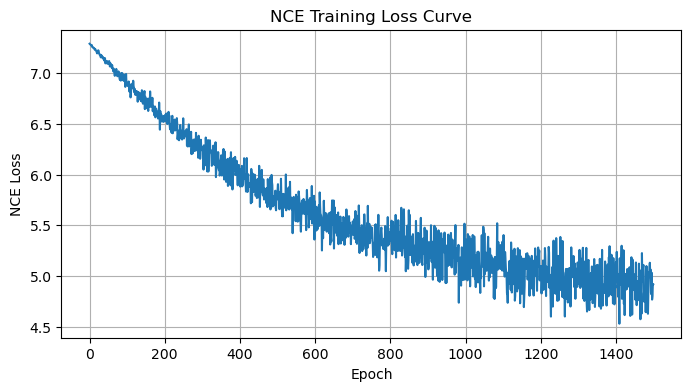

(context items =[8 6 1], 5)
Most relevant item: 4
(context items =[5 6 1], 7)
Most relevant item: 5
(context items =[4 5 6], 7)
Most relevant item: 5
(context items =[3 2 4], 5)
Most relevant item: 3
(context items =[4 0 5], 6)
Most relevant item: 5


In [58]:
# Plot the loss curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('NCE Loss')
plt.title('NCE Training Loss Curve')
plt.grid(True)
plt.show()

# Affichage de quelques transactions
for t in transactions_ic[:5]:
    print(t)
    print('Most relevant item:', np.array([t[0].score(i) for i in range(I)]).argmax())